# Assignment 5: Comparative Binary Classification with XGBoost
## Bankruptcy Prediction

**Name:** Tenzing Nima Tamang 

**Dataset:** `data.csv`
  
**Random Seed:** 42


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DEFAULT_THRESHOLD = 0.50
FINAL_BETA = 2
TOP_N_FEATURES = 25

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_theme(style="whitegrid", context="notebook")


In [2]:
def resolve_data_path():
    candidate_paths = [
        Path(r"C:\Users\A S U S\aidi-1204-project\ml-workshop\ml-workshop\training\data.csv"),
        Path("ml-workshop") / "ml-workshop" / "training" / "data.csv",
        Path("ml-workshop") / "training" / "data.csv",
        Path("training") / "data.csv",
        Path("data.csv"),
    ]
    for path in candidate_paths:
        if path.exists():
            return path.resolve()
    raise FileNotFoundError("Could not find training/data.csv")

DATA_PATH = resolve_data_path()
print(DATA_PATH)


C:\Users\A S U S\aidi-1204-project\ml-workshop\ml-workshop\training\data.csv


## 1. Problem Definition

- **Target variable:** `Bankrupt?`
- **Positive class:** `1`, meaning the company went bankrupt
- **Why it matters:** A risk team can prioritize companies with elevated bankruptcy risk before losses occur
- **Class balance:** This is an imbalanced classification problem, so accuracy alone is misleading
- **Primary discrimination metric:** PR-AUC
- **Calibration assessment:** Brier score plus a calibration curve for the final model


## 2. Quick EDA


In [3]:
df = pd.read_csv(DATA_PATH)
target_col = "Bankrupt?"

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (6819, 96)


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.3706,0.4244,0.4057,0.6015,0.6015,0.9990,0.7969,0.8088,0.3026,0.7810,0.0001,0.0000,0.4581,0.0007,0.0000,0.1479,0.1479,0.1479,0.1691,0.3117,0.0176,0.0959,0.1387,0.0221,0.8482,0.6890,0.6890,0.2175,4980000000.0000,0.0003,0.2631,0.3637,0.0023,0.0012,0.6300,0.0213,0.2076,0.7924,0.0050,0.3903,0.0065,0.0959,0.1378,0.3980,0.0870,0.0018,0.0035,0.0002,0.0001,0.0329,0.0342,0.3929,0.0371,0.6728,0.1667,0.1906,0.0041,0.0020,0.0001,0.1473,0.3340,0.2769,0.0010,0.6763,0.7213,0.3391,0.0256,0.9032,0.0020,0.0649,701000000.0000,6550000000.0000,0.5938,458000000.0000,0.6716,0.4242,0.6763,0.3391,0.1265,0.6376,0.4586,0.5204,0.3129,0.1183,0,0.7168,0.0092,0.6229,0.6015,0.8279,0.2902,0.0266,0.5641,1,0.0165
1,1,0.4643,0.5382,0.5167,0.6102,0.6102,0.9989,0.7974,0.8093,0.3036,0.7815,0.0003,0.0000,0.4619,0.0006,0.0000,0.1823,0.1823,0.1823,0.2089,0.3181,0.0211,0.0937,0.1699,0.0221,0.8481,0.6897,0.6897,0.2176,6110000000.0000,0.0004,0.2645,0.3767,0.0060,0.0040,0.6352,0.0125,0.1712,0.8288,0.0051,0.3768,0.0058,0.0937,0.1690,0.3977,0.0645,0.0013,0.0049,9360000000.0000,719000000.0000,0.0255,0.0069,0.3916,0.0123,0.7511,0.1272,0.1824,0.0149,0.0041,0.0014,0.0570,0.3411,0.2896,0.0052,0.3086,0.7320,0.3297,0.0239,0.9311,0.0022,0.0255,0.0001,7700000000.0000,0.5939,2490000000.0000,0.6716,0.4688,0.3086,0.3297,0.1209,0.6411,0.4590,0.5671,0.3142,0.0478,0,0.

In [4]:
target_counts = df[target_col].value_counts().sort_index()
target_pct = df[target_col].value_counts(normalize=True).sort_index() * 100

eda_summary = pd.DataFrame({
    "class": target_counts.index,
    "count": target_counts.values,
    "pct": target_pct.values,
})

missing_values_total = int(df.isna().sum().sum())
duplicate_rows = int(df.duplicated().sum())

display(eda_summary)
print("Total missing values:", missing_values_total)
print("Duplicate rows:", duplicate_rows)


,class,count,pct
0,0,6599,96.7737
1,1,220,3.2263


Total missing values: 0
Duplicate rows: 0


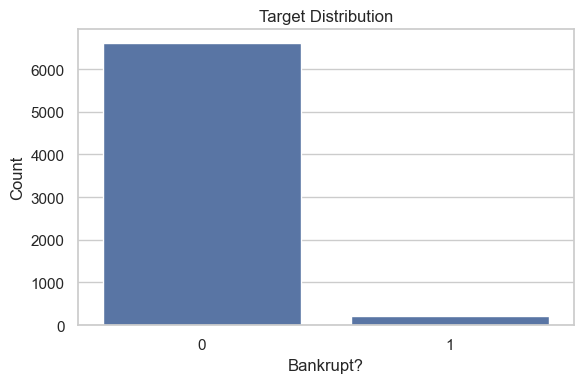

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col)
plt.title("Target Distribution")
plt.xlabel("Bankrupt?")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [6]:
positive_rate = df[target_col].mean() * 100

display(Markdown(
    f"""
### Short EDA Observation

- The dataset has **{df.shape[0]:,} rows** and **{df.shape[1]} columns**.
- The positive class rate is about **{positive_rate:.2f}%**, so this is strongly imbalanced.
- Missing values across the dataset: **{missing_values_total}**.
- Duplicate rows found: **{duplicate_rows}**.
- Because bankruptcy is rare, I will not use accuracy as my primary metric.
"""
))



### Short EDA Observation

- The dataset has **6,819 rows** and **96 columns**.
- The positive class rate is about **3.23%**, so this is strongly imbalanced.
- Missing values across the dataset: **0**.
- Duplicate rows found: **0**.
- Because bankruptcy is rare, I will not use accuracy as my primary metric.


## 3. Train, Validation, Test Split

- Train: 70%
- Validation: 15%
- Test: 15%
- Stratified sampling is used
- The test set will stay untouched until the final evaluation section


In [7]:
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (4773, 95) (4773,)
Validation: (1023, 95) (1023,)
Test: (1023, 95) (1023,)


In [8]:
def split_balance(name, y_split):
    counts = y_split.value_counts().sort_index()
    pct = y_split.value_counts(normalize=True).sort_index() * 100
    return pd.DataFrame({
        "split": name,
        "class": counts.index,
        "count": counts.values,
        "pct": pct.values
    })

split_balance_df = pd.concat([
    split_balance("train", y_train),
    split_balance("validation", y_val),
    split_balance("test", y_test),
], ignore_index=True)

display(split_balance_df)


,split,class,count,pct
0,train,0,4619,96.7735
1,train,1,154,3.2265
2,validation,0,990,96.7742
3,validation,1,33,3.2258
4,test,0,990,96.7742
5,test,1,33,3.2258


## 4. Preprocessing

- The target column is removed from the feature matrix
- Numeric and non-numeric columns are checked
- Median imputation is used if missing values exist
- Scaling is applied only to logistic regression
- A brief leakage keyword check is included


In [9]:
numeric_columns = X_train.select_dtypes(include=np.number).columns.tolist()
non_numeric_columns = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric feature count:", len(numeric_columns))
print("Non-numeric feature count:", len(non_numeric_columns))
print("Non-numeric columns:", non_numeric_columns if non_numeric_columns else "None")


Numeric feature count: 95
Non-numeric feature count: 0
Non-numeric columns: None


In [10]:
print("Missing values in X_train:", int(X_train.isna().sum().sum()))
print("Missing values in X_val:", int(X_val.isna().sum().sum()))
print("Missing values in X_test:", int(X_test.isna().sum().sum()))


Missing values in X_train: 0
Missing values in X_val: 0
Missing values in X_test: 0


In [11]:
leakage_keywords = ["bankrupt", "default", "insolv", "failure", "target"]
suspicious_columns = [
    col for col in X.columns
    if any(keyword in col.lower() for keyword in leakage_keywords)
]

print("Potential leakage columns:", suspicious_columns if suspicious_columns else "None obvious")


Potential leakage columns: None obvious


## 5. Feature Sets

- **Feature Set A:** all usable features after basic cleaning
- **Feature Set B:** top 25 features selected using a training-only XGBoost feature importance model


In [12]:
def build_logistic_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])

def build_xgb_pipeline(**xgb_params):
    params = {
        "random_state": RANDOM_STATE,
        "n_estimators": 250,
        "learning_rate": 0.05,
        "max_depth": 3,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "n_jobs": -1,
    }
    params.update(xgb_params)
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(**params)),
    ])

def get_model_step(estimator):
    return estimator.named_steps["model"] if isinstance(estimator, Pipeline) else estimator

def get_feature_importance_df(estimator, feature_names):
    model = get_model_step(estimator)
    if hasattr(model, "feature_importances_"):
        values = model.feature_importances_
    elif hasattr(model, "coef_"):
        values = np.abs(model.coef_).ravel()
    else:
        raise ValueError("No feature importance available.")
    return (
        pd.DataFrame({"feature": feature_names, "importance": values})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

feature_set_a = X_train.columns.tolist()

feature_selector = build_xgb_pipeline(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.80,
    colsample_bytree=0.80,
)
feature_selector.fit(X_train[feature_set_a], y_train)

feature_importance_a = get_feature_importance_df(feature_selector, feature_set_a)
feature_set_b = feature_importance_a.head(TOP_N_FEATURES)["feature"].tolist()

print("Feature Set A size:", len(feature_set_a))
print("Feature Set B size:", len(feature_set_b))
display(feature_importance_a.head(10))


Feature Set A size: 95
Feature Set B size: 25


,feature,importance
0,Persistent EPS in the Last Four Seasons,0.0836
1,Borrowing dependency,0.0597
2,Net Value Growth Rate,0.0491
3,Net worth/Assets,0.0472
4,Continuous interest rate (after tax),0.0329
5,Net Value Per Share (B),0.0256
6,Quick Ratio,0.0248
7,Current Liability to Equity,0.0221
8,Net Income to Stockholder's Equity,0.0187
9,Non-industry income and expenditure/revenue,0.0177


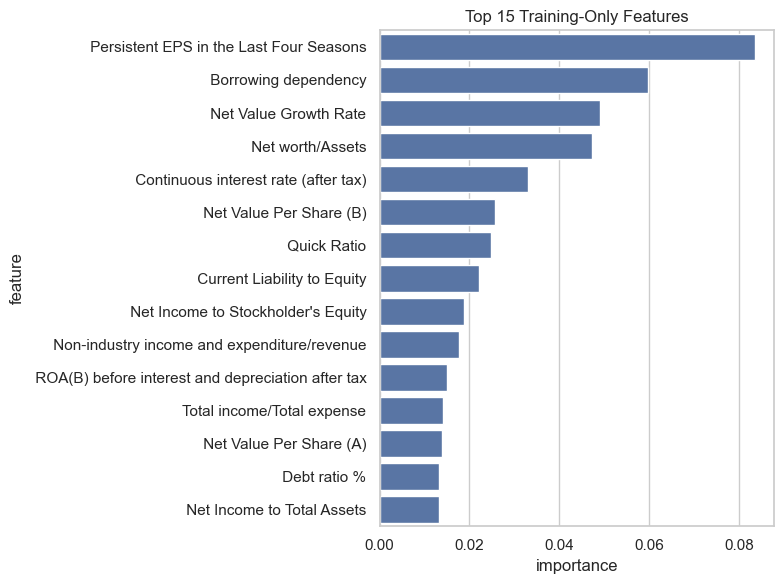

In [13]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=feature_importance_a.head(15),
    x="importance",
    y="feature",
    orient="h"
)
plt.title("Top 15 Training-Only Features")
plt.tight_layout()
plt.show()


In [14]:
display(Markdown(
    f"""
### Feature Set B Notes

- Feature Set B was selected using a training-only XGBoost feature importance model.
- I kept the top **{len(feature_set_b)}** features.
- This avoids using the test set during feature selection.
- The smaller feature set should be easier to explain if performance stays close to Feature Set A.
"""
))



### Feature Set B Notes

- Feature Set B was selected using a training-only XGBoost feature importance model.
- I kept the top **25** features.
- This avoids using the test set during feature selection.
- The smaller feature set should be easier to explain if performance stays close to Feature Set A.


## 6. Reusable Evaluation Function


In [15]:
def threshold_metrics(y_true, prob, threshold=0.50, beta=2):
    pred = (prob >= threshold).astype(int)
    return {
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "fbeta": fbeta_score(y_true, pred, beta=beta, zero_division=0),
        "accuracy": accuracy_score(y_true, pred),
    }

def evaluate_model(
    exp_id,
    model_name,
    feature_set,
    estimator,
    X_train_data,
    y_train_data,
    X_val_data,
    y_val_data,
    main_settings,
    threshold=0.50,
    beta=2,
    notes=""
):
    estimator.fit(X_train_data, y_train_data)

    prob_train = estimator.predict_proba(X_train_data)[:, 1]
    prob_val = estimator.predict_proba(X_val_data)[:, 1]

    tm = threshold_metrics(y_val_data, prob_val, threshold=threshold, beta=beta)

    row = {
        "exp_id": exp_id,
        "model": model_name,
        "feature_set": feature_set,
        "main_settings": main_settings,
        "train_pr_auc": average_precision_score(y_train_data, prob_train),
        "val_pr_auc": average_precision_score(y_val_data, prob_val),
        "overfit_gap": average_precision_score(y_train_data, prob_train) - average_precision_score(y_val_data, prob_val),
        "val_roc_auc": roc_auc_score(y_val_data, prob_val),
        "val_brier": brier_score_loss(y_val_data, prob_val),
        "threshold": threshold,
        "val_precision": tm["precision"],
        "val_recall": tm["recall"],
        "val_f1_or_f2": tm["fbeta"],
        "selected_finalist": "No",
        "notes": notes,
    }
    return row, estimator

def find_best_threshold(y_true, prob, beta=2, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.55, 0.01)

    rows = []
    for threshold in thresholds:
        tm = threshold_metrics(y_true, prob, threshold=threshold, beta=beta)
        rows.append({
            "threshold": threshold,
            "precision": tm["precision"],
            "recall": tm["recall"],
            "fbeta": tm["fbeta"],
            "accuracy": tm["accuracy"],
        })

    return pd.DataFrame(rows).sort_values(
        ["fbeta", "recall", "precision"],
        ascending=[False, False, False]
    ).reset_index(drop=True)


In [16]:
results_rows = []
trained_models = {}


## 7. Experiment 1 — Simple Baseline
- Model: Logistic Regression
- Feature Set: A


In [17]:
exp_1_model = build_logistic_pipeline()
exp_1_row, exp_1_fitted = evaluate_model(
    exp_id=1,
    model_name="Logistic Regression",
    feature_set="A",
    estimator=exp_1_model,
    X_train_data=X_train[feature_set_a],
    y_train_data=y_train,
    X_val_data=X_val[feature_set_a],
    y_val_data=y_val,
    main_settings="median impute + scale + logistic regression",
    threshold=DEFAULT_THRESHOLD,
    beta=FINAL_BETA,
    notes="Simple baseline on all cleaned features.",
)
results_rows.append(exp_1_row)
trained_models[1] = {"estimator": exp_1_fitted, "features": feature_set_a}


## 8. Experiment 2 — XGBoost Baseline
- Model: XGBoost
- Feature Set: A


In [18]:
exp_2_model = build_xgb_pipeline(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.80,
    colsample_bytree=0.80,
)
exp_2_row, exp_2_fitted = evaluate_model(
    exp_id=2,
    model_name="XGBoost Baseline",
    feature_set="A",
    estimator=exp_2_model,
    X_train_data=X_train[feature_set_a],
    y_train_data=y_train,
    X_val_data=X_val[feature_set_a],
    y_val_data=y_val,
    main_settings="n_estimators=250, lr=0.05, depth=3",
    threshold=DEFAULT_THRESHOLD,
    beta=FINAL_BETA,
    notes="First strong nonlinear model on all features.",
)
results_rows.append(exp_2_row)
trained_models[2] = {"estimator": exp_2_fitted, "features": feature_set_a}


## 9. Experiment 3 — XGBoost with Imbalance Handling
- Model: XGBoost
- Feature Set: A
- Imbalance handling: `scale_pos_weight`


In [19]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 2))

exp_3_model = build_xgb_pipeline(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.80,
    colsample_bytree=0.80,
    scale_pos_weight=float(scale_pos_weight),
)
exp_3_row, exp_3_fitted = evaluate_model(
    exp_id=3,
    model_name="XGBoost Imbalance",
    feature_set="A",
    estimator=exp_3_model,
    X_train_data=X_train[feature_set_a],
    y_train_data=y_train,
    X_val_data=X_val[feature_set_a],
    y_val_data=y_val,
    main_settings=f"scale_pos_weight={scale_pos_weight:.2f}, depth=3, lr=0.05",
    threshold=DEFAULT_THRESHOLD,
    beta=FINAL_BETA,
    notes="Handles class imbalance directly during fitting.",
)
results_rows.append(exp_3_row)
trained_models[3] = {"estimator": exp_3_fitted, "features": feature_set_a}


scale_pos_weight: 29.99


## 10. Experiment 4 — Lightly Tuned XGBoost
- Model: XGBoost
- Feature Set: A
- Tuning approach: small manual search over 5 configurations using train and validation only


In [20]:
tuning_candidates = [
    {
        "n_estimators": 350, "learning_rate": 0.05, "max_depth": 2,
        "subsample": 0.80, "colsample_bytree": 0.70,
        "min_child_weight": 5, "reg_lambda": 2.0, "gamma": 0.10
    },
    {
        "n_estimators": 450, "learning_rate": 0.04, "max_depth": 3,
        "subsample": 0.80, "colsample_bytree": 0.80,
        "min_child_weight": 3, "reg_lambda": 2.0, "reg_alpha": 0.10
    },
    {
        "n_estimators": 500, "learning_rate": 0.03, "max_depth": 3,
        "subsample": 0.75, "colsample_bytree": 0.75,
        "min_child_weight": 4, "reg_lambda": 3.0, "reg_alpha": 0.20, "gamma": 0.20
    },
    {
        "n_estimators": 300, "learning_rate": 0.08, "max_depth": 4,
        "subsample": 0.90, "colsample_bytree": 0.80,
        "min_child_weight": 2, "reg_lambda": 1.5
    },
    {
        "n_estimators": 550, "learning_rate": 0.03, "max_depth": 2,
        "subsample": 0.85, "colsample_bytree": 0.70,
        "min_child_weight": 6, "reg_lambda": 3.0, "gamma": 0.15
    },
]

tuning_rows = []
for idx, params in enumerate(tuning_candidates, start=1):
    candidate_model = build_xgb_pipeline(**params)
    candidate_model.fit(X_train[feature_set_a], y_train)

    train_prob = candidate_model.predict_proba(X_train[feature_set_a])[:, 1]
    val_prob = candidate_model.predict_proba(X_val[feature_set_a])[:, 1]

    tuning_rows.append({
        "candidate_id": idx,
        "params_dict": params,
        "params": str(params),
        "train_pr_auc": average_precision_score(y_train, train_prob),
        "val_pr_auc": average_precision_score(y_val, val_prob),
        "val_brier": brier_score_loss(y_val, val_prob),
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values(
    ["val_pr_auc", "val_brier"],
    ascending=[False, True]
).reset_index(drop=True)

display(tuning_df[["candidate_id", "params", "train_pr_auc", "val_pr_auc", "val_brier"]])

best_tuned_params = tuning_df.loc[0, "params_dict"]
print("Best tuned params:", best_tuned_params)


,candidate_id,params,train_pr_auc,val_pr_auc,val_brier
0,4,"{'n_estimators': 300, 'learning_rate': 0.08, '...",1.0000,0.6012,0.0201
1,2,"{'n_estimators': 450, 'learning_rate': 0.04, '...",0.9967,0.5877,0.0196
2,1,"{'n_estimators': 350, 'learning_rate': 0.05, '...",0.8877,0.5803,0.0198
3,3,"{'n_estimators': 500, 'learning_rate': 0.03, '...",0.9759,0.5718,0.0200
4,5,"{'n_estimators': 550, 'learning_rate': 0.03, '...",0.8499,0.5663,0.0201


Best tuned params: {'n_estimators': 300, 'learning_rate': 0.08, 'max_depth': 4, 'subsample': 0.9, 'colsample_bytree': 0.8, 'min_child_weight': 2, 'reg_lambda': 1.5}


In [21]:
exp_4_model = build_xgb_pipeline(**best_tuned_params)
exp_4_row, exp_4_fitted = evaluate_model(
    exp_id=4,
    model_name="XGBoost Tuned",
    feature_set="A",
    estimator=exp_4_model,
    X_train_data=X_train[feature_set_a],
    y_train_data=y_train,
    X_val_data=X_val[feature_set_a],
    y_val_data=y_val,
    main_settings=str(best_tuned_params),
    threshold=DEFAULT_THRESHOLD,
    beta=FINAL_BETA,
    notes="Best setting from a 5-candidate manual search.",
)
results_rows.append(exp_4_row)
trained_models[4] = {"estimator": exp_4_fitted, "features": feature_set_a}


## 11. Experiment 5 — XGBoost with Selected Features
- Model: XGBoost
- Feature Set: B


In [22]:
exp_5_model = build_xgb_pipeline(**best_tuned_params)
exp_5_row, exp_5_fitted = evaluate_model(
    exp_id=5,
    model_name="XGBoost Selected Features",
    feature_set="B",
    estimator=exp_5_model,
    X_train_data=X_train[feature_set_b],
    y_train_data=y_train,
    X_val_data=X_val[feature_set_b],
    y_val_data=y_val,
    main_settings=f"Top {len(feature_set_b)} features + tuned XGBoost",
    threshold=DEFAULT_THRESHOLD,
    beta=FINAL_BETA,
    notes="Tests whether a smaller feature set stays competitive.",
)
results_rows.append(exp_5_row)
trained_models[5] = {"estimator": exp_5_fitted, "features": feature_set_b}


## 12. 5-Row Experiment Table


In [23]:
results_df = pd.DataFrame(results_rows)

winner_idx = results_df.sort_values(
    ["val_pr_auc", "val_brier", "overfit_gap"],
    ascending=[False, True, True]
).index[0]

results_df.loc[winner_idx, "selected_finalist"] = "Yes"

display_cols = [
    "exp_id",
    "model",
    "feature_set",
    "main_settings",
    "train_pr_auc",
    "val_pr_auc",
    "overfit_gap",
    "val_roc_auc",
    "val_brier",
    "threshold",
    "val_precision",
    "val_recall",
    "val_f1_or_f2",
    "selected_finalist",
    "notes",
]

display(results_df[display_cols].sort_values("exp_id").reset_index(drop=True))


,exp_id,model,feature_set,main_settings,train_pr_auc,val_pr_auc,overfit_gap,val_roc_auc,val_brier,threshold,val_precision,val_recall,val_f1_or_f2,selected_finalist,notes
0,1,Logistic Regression,A,median impute + scale + logistic regression,0.5308,0.2587,0.2721,0.8766,0.0316,0.5000,0.3333,0.1818,0.2000,No,Simple baseline on all cleaned features.
1,2,XGBoost Baseline,A,"n_estimators=250, lr=0.05, depth=3",0.9933,0.5808,0.4125,0.9627,0.0198,0.5000,0.6923,0.2727,0.3103,No,First strong nonlinear model on all features.
2,3,XGBoost Imbalance,A,"scale_pos_weight=29.99, depth=3, lr=0.05",0.9947,0.4524,0.5423,0.9574,0.0334,0.5000,0.4000,0.7273,0.6250,No,Handles class imbalance directly during fitting.
3,4,XGBoost Tuned,A,"{'n_estimators': 300, 'learning_rate': 0.08, '...",1.0000,0.6012,0.3988,0.9650,0.0201,0.5000,0.7692,0.3030,0.3448,Yes,Best setting from a 5-candidate manual search.
4,5,XGBoost Selected Features,B,Top 25 features + tuned XGBoost,0.9990,0.4916,0.5074,0.9510,0.0216,0.5000,0.6667,0.3030,0.3401,No,Tests whether a smaller feature set stays comp...


In [24]:
selected_row = results_df.loc[winner_idx]

display(Markdown(
    f"""
### Final Model Selection Notes

- The selected finalist is **Experiment {int(selected_row['exp_id'])}: {selected_row['model']}**.
- It had the strongest validation PR-AUC under the assignment rule: **{selected_row['val_pr_auc']:.4f}**.
- Its validation Brier score was **{selected_row['val_brier']:.4f}**.
- The overfit gap was **{selected_row['overfit_gap']:.4f}**.
- The test set has still not been used at this point.
"""
))



### Final Model Selection Notes

- The selected finalist is **Experiment 4: XGBoost Tuned**.
- It had the strongest validation PR-AUC under the assignment rule: **0.6012**.
- Its validation Brier score was **0.0201**.
- The overfit gap was **0.3988**.
- The test set has still not been used at this point.


## 13. Threshold Selection for the Final Model

Threshold choice is done only for the selected final model, using the validation set.  
Because false negatives matter more, this notebook uses the threshold that maximizes **validation F2-score**.


In [25]:
final_exp_id = int(selected_row["exp_id"])
final_estimator = trained_models[final_exp_id]["estimator"]
final_features = trained_models[final_exp_id]["features"]

val_prob_final = final_estimator.predict_proba(X_val[final_features])[:, 1]
threshold_df = find_best_threshold(y_val, val_prob_final, beta=FINAL_BETA)
best_threshold = float(threshold_df.loc[0, "threshold"])

display(threshold_df.head(10))
print(f"Chosen final threshold from validation F{FINAL_BETA}: {best_threshold:.2f}")


,threshold,precision,recall,fbeta,accuracy
0,0.0500,0.4483,0.7879,0.6842,0.9619
1,0.0600,0.4483,0.7879,0.6842,0.9619
2,0.0700,0.4444,0.7273,0.6452,0.9619
3,0.0800,0.4792,0.6970,0.6389,0.9658
4,0.0900,0.4783,0.6667,0.6180,0.9658
5,0.1000,0.4884,0.6364,0.6000,0.9668
6,0.1100,0.4884,0.6364,0.6000,0.9668
7,0.1200,0.4884,0.6364,0.6000,0.9668
8,0.1300,0.4884,0.6364,0.6000,0.9668
9,0.2100,0.6129,0.5758,0.5828,0.9746


Chosen final threshold from validation F2: 0.05


## 14. Final Test Evaluation

The test set is used only now, after the final model and final threshold have been chosen.


In [26]:
test_prob_final = final_estimator.predict_proba(X_test[final_features])[:, 1]
test_pred_final = (test_prob_final >= best_threshold).astype(int)

test_pr_auc = average_precision_score(y_test, test_prob_final)
test_roc_auc = roc_auc_score(y_test, test_prob_final)
test_brier = brier_score_loss(y_test, test_prob_final)
test_precision = precision_score(y_test, test_pred_final, zero_division=0)
test_recall = recall_score(y_test, test_pred_final, zero_division=0)
test_fbeta = fbeta_score(y_test, test_pred_final, beta=FINAL_BETA, zero_division=0)
test_accuracy = accuracy_score(y_test, test_pred_final)
test_cm = confusion_matrix(y_test, test_pred_final)

test_results_df = pd.DataFrame({
    "metric": [
        "test_pr_auc",
        "test_roc_auc",
        "test_brier",
        "test_precision",
        "test_recall",
        f"test_f{FINAL_BETA}",
        "test_accuracy",
        "final_threshold",
    ],
    "value": [
        test_pr_auc,
        test_roc_auc,
        test_brier,
        test_precision,
        test_recall,
        test_fbeta,
        test_accuracy,
        best_threshold,
    ],
})

display(test_results_df)
print("Confusion matrix:\n", test_cm)


,metric,value
0,test_pr_auc,0.4977
1,test_roc_auc,0.9493
2,test_brier,0.0232
3,test_precision,0.3878
4,test_recall,0.5758
5,test_f2,0.5249
6,test_accuracy,0.9570
7,final_threshold,0.0500


Confusion matrix:
 [[960  30]
 [ 14  19]]


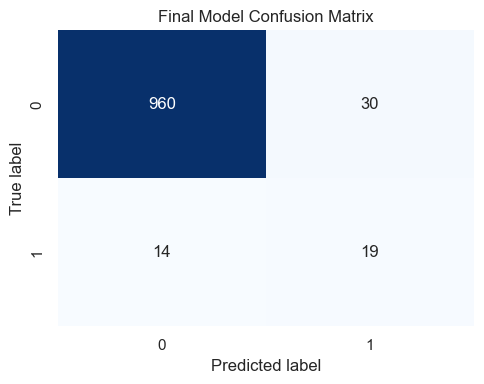

In [27]:
plt.figure(figsize=(5, 4))
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


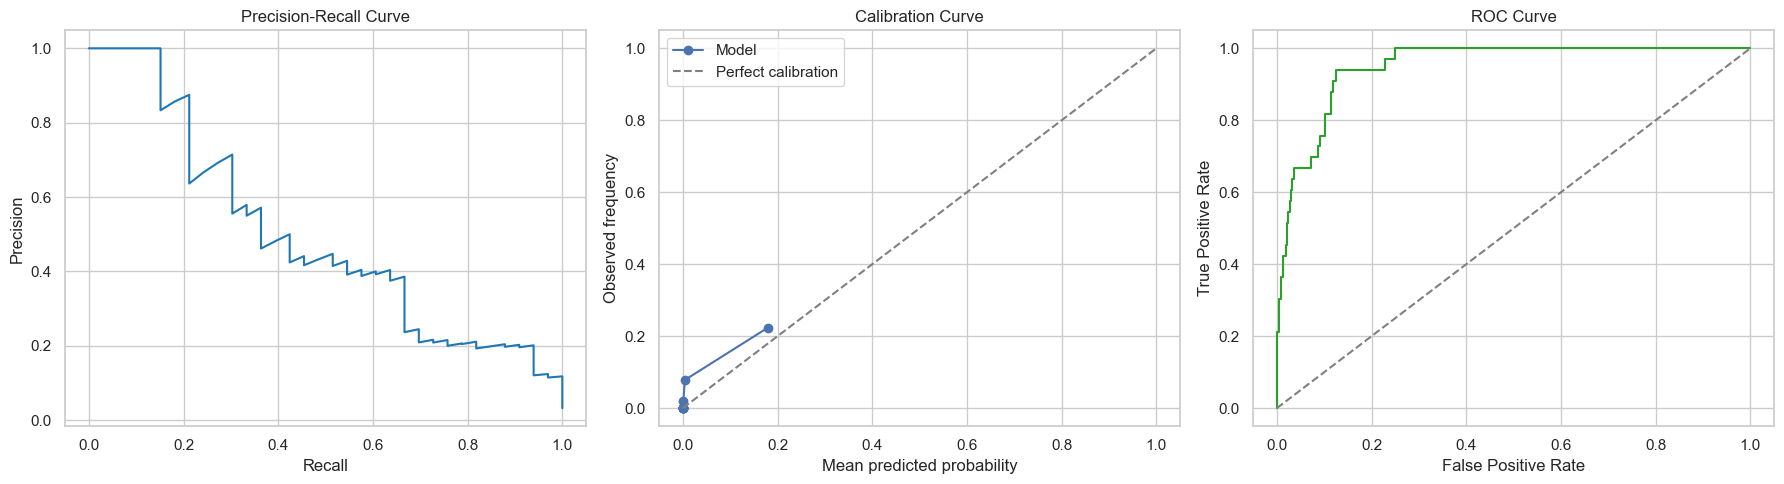

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

precisions, recalls, _ = precision_recall_curve(y_test, test_prob_final)
axes[0].plot(recalls, precisions, color="tab:blue")
axes[0].set_title("Precision-Recall Curve")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")

prob_true, prob_pred = calibration_curve(y_test, test_prob_final, n_bins=10, strategy="quantile")
axes[1].plot(prob_pred, prob_true, marker="o", label="Model")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
axes[1].set_title("Calibration Curve")
axes[1].set_xlabel("Mean predicted probability")
axes[1].set_ylabel("Observed frequency")
axes[1].legend()

fpr, tpr, _ = roc_curve(y_test, test_prob_final)
axes[2].plot(fpr, tpr, color="tab:green")
axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[2].set_title("ROC Curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")

plt.tight_layout()
plt.show()


## 15. Calibration Check


In [29]:
calibration_error = float(np.mean(np.abs(prob_true - prob_pred)))
top_decile_cutoff = np.quantile(test_prob_final, 0.90)
top_decile_mask = test_prob_final >= top_decile_cutoff
top_decile_pred_rate = float(test_prob_final[top_decile_mask].mean())
top_decile_observed_rate = float(y_test[top_decile_mask].mean())
overall_bankruptcy_rate = float(y_test.mean())

if calibration_error < 0.05:
    calibration_comment = "The calibration curve is fairly close to the diagonal overall."
elif calibration_error < 0.10:
    calibration_comment = "The calibration curve shows some deviation from perfect calibration."
else:
    calibration_comment = "The calibration curve shows noticeable calibration error."

if top_decile_observed_rate > top_decile_pred_rate:
    confidence_comment = "In the highest-risk bucket, the model looks somewhat under-confident."
elif top_decile_observed_rate < top_decile_pred_rate:
    confidence_comment = "In the highest-risk bucket, the model looks somewhat over-confident."
else:
    confidence_comment = "In the highest-risk bucket, predicted and observed risk are very similar."

display(Markdown(
    f"""
### Calibration Discussion

- Test Brier score: **{test_brier:.4f}**.
- {calibration_comment}
- The top-risk group has mean predicted risk **{top_decile_pred_rate:.4f}** and observed bankruptcy rate **{top_decile_observed_rate:.4f}**.
- The overall test bankruptcy rate is **{overall_bankruptcy_rate:.4f}**, so the ranking is useful if the top-risk bucket is materially higher.
- {confidence_comment}
"""
))



### Calibration Discussion

- Test Brier score: **0.0232**.
- The calibration curve is fairly close to the diagonal overall.
- The top-risk group has mean predicted risk **0.1792** and observed bankruptcy rate **0.2233**.
- The overall test bankruptcy rate is **0.0323**, so the ranking is useful if the top-risk bucket is materially higher.
- In the highest-risk bucket, the model looks somewhat under-confident.


## 16. Interpretability


In [30]:
importance_df_final = get_feature_importance_df(final_estimator, final_features).head(15)
display(importance_df_final)


,feature,importance
0,Persistent EPS in the Last Four Seasons,0.0765
1,Borrowing dependency,0.0615
2,Net Value Growth Rate,0.0580
3,Net worth/Assets,0.0509
4,ROA(B) before interest and depreciation after...,0.0291
5,Non-industry income and expenditure/revenue,0.0243
6,Quick Ratio,0.0242
7,Continuous interest rate (after tax),0.0194
8,Net Value Per Share (B),0.0188
9,Total debt/Total net worth,0.0175


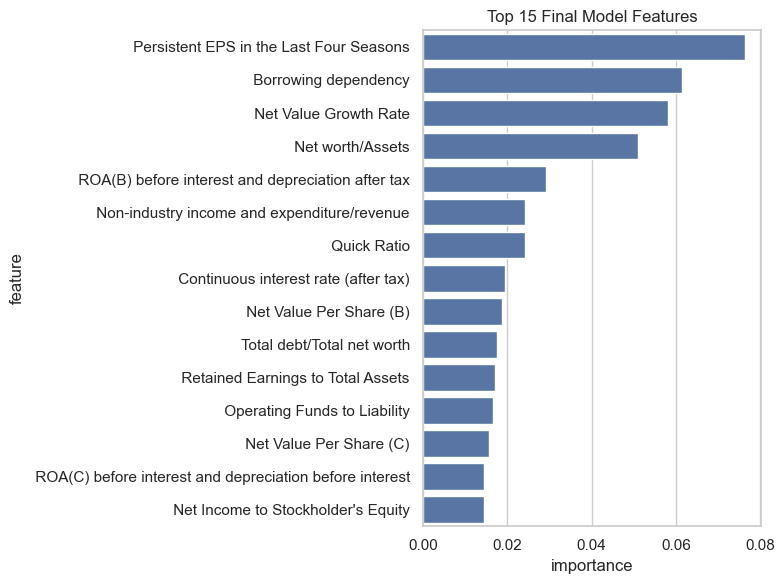

In [31]:
plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df_final, x="importance", y="feature", orient="h")
plt.title("Top 15 Final Model Features")
plt.tight_layout()
plt.show()


In [32]:
top_feature = importance_df_final.iloc[0]["feature"]

display(Markdown(
    f"""
### Feature Importance Notes

- The most important feature in the final model is **{top_feature}**.
- This is useful if it aligns with how financial health or leverage should relate to bankruptcy risk.
- A limitation is that feature importance does not prove causality and can be unstable when predictors are correlated.
"""
))



### Feature Importance Notes

- The most important feature in the final model is ** Persistent EPS in the Last Four Seasons**.
- This is useful if it aligns with how financial health or leverage should relate to bankruptcy risk.
- A limitation is that feature importance does not prove causality and can be unstable when predictors are correlated.


## 17. Metric Choice Explanation


Because the positive class is rare, accuracy is not a reliable main metric in this problem.  
A model can achieve very high accuracy by predicting almost every company as non-bankrupt, while still missing the companies that matter most.  
PR-AUC is a better discrimination metric here because it focuses on how well the model identifies the rare positive class.  
Brier score answers a different question: whether the predicted probabilities are numerically credible, not just well ranked.  
Thresholded metrics such as precision, recall, and F2-score are still useful, but they describe one operating point rather than full probability calibration.


## 18. Feature Set Comparison Notes


In [33]:
feature_set_a_row = results_df.loc[results_df["exp_id"] == 4].iloc[0]
feature_set_b_row = results_df.loc[results_df["exp_id"] == 5].iloc[0]

if feature_set_b_row["val_pr_auc"] > feature_set_a_row["val_pr_auc"]:
    performance_note = "Feature Set B performed better than the tuned full-feature model."
elif feature_set_b_row["val_pr_auc"] < feature_set_a_row["val_pr_auc"]:
    performance_note = "Feature Set B performed slightly worse than the tuned full-feature model."
else:
    performance_note = "Feature Set B performed about the same as the tuned full-feature model."

display(Markdown(
    f"""
### Feature Set B Summary

- Feature Set B was created from training-only XGBoost feature importance.
- It kept **{len(feature_set_b)}** features.
- {performance_note}
- The smaller feature set is easier to explain because it reduces the number of variables to discuss.
"""
))



### Feature Set B Summary

- Feature Set B was created from training-only XGBoost feature importance.
- It kept **25** features.
- Feature Set B performed slightly worse than the tuned full-feature model.
- The smaller feature set is easier to explain because it reduces the number of variables to discuss.


## 19. Overfitting Discussion


In [34]:
final_overfit_gap = float(selected_row["overfit_gap"])

if final_overfit_gap <= 0.05:
    overfit_comment = "The overfit gap is small and is usually acceptable."
elif final_overfit_gap <= 0.10:
    overfit_comment = "The overfit gap is moderate, so the model should be watched carefully."
else:
    overfit_comment = "The overfit gap is large and suggests overfitting."

display(Markdown(
    f"""
### Overfitting Check

- Final model train PR-AUC: **{selected_row['train_pr_auc']:.4f}**
- Final model validation PR-AUC: **{selected_row['val_pr_auc']:.4f}**
- Overfit gap: **{final_overfit_gap:.4f}**
- {overfit_comment}
"""
))



### Overfitting Check

- Final model train PR-AUC: **1.0000**
- Final model validation PR-AUC: **0.6012**
- Overfit gap: **0.3988**
- The overfit gap is large and suggests overfitting.


## 20. AI Usage


- AI tool used: Codex in VS Code.
- It helped me structure the notebook, build a reusable evaluation function, and organize the five experiments.
- One thing I verified myself: that the test set stayed untouched until the final evaluation section.
- One thing I fixed myself: replace this line with a real example from your own work.


## 21. Short Summary Draft


In [35]:
summary_lines = [
    "### Jot-Note Summary Draft",
    f"- Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns, positive class rate {positive_rate:.2f}%.",
    "- Primary discrimination metric: PR-AUC.",
    "- Primary calibration metric: Brier score.",
    f"- Winning experiment: Experiment {final_exp_id} ({selected_row['model']}).",
    f"- Validation PR-AUC: {selected_row['val_pr_auc']:.4f}.",
    f"- Validation Brier score: {selected_row['val_brier']:.4f}.",
    f"- Final threshold chosen on validation set: {best_threshold:.2f}.",
    f"- Test PR-AUC: {test_pr_auc:.4f}.",
    f"- Test ROC-AUC: {test_roc_auc:.4f}.",
    f"- Test Brier score: {test_brier:.4f}.",
    f"- Test precision: {test_precision:.4f}.",
    f"- Test recall: {test_recall:.4f}.",
    f"- Test F{FINAL_BETA}: {test_fbeta:.4f}.",
    f"- Confusion matrix: TN={test_cm[0,0]}, FP={test_cm[0,1]}, FN={test_cm[1,0]}, TP={test_cm[1,1]}.",
]
display(Markdown("\n".join(summary_lines)))


### Jot-Note Summary Draft
- Dataset: 6,819 rows, 96 columns, positive class rate 3.23%.
- Primary discrimination metric: PR-AUC.
- Primary calibration metric: Brier score.
- Winning experiment: Experiment 4 (XGBoost Tuned).
- Validation PR-AUC: 0.6012.
- Validation Brier score: 0.0201.
- Final threshold chosen on validation set: 0.05.
- Test PR-AUC: 0.4977.
- Test ROC-AUC: 0.9493.
- Test Brier score: 0.0232.
- Test precision: 0.3878.
- Test recall: 0.5758.
- Test F2: 0.5249.
- Confusion matrix: TN=960, FP=30, FN=14, TP=19.